# GANisme — 05. Modèle n°2 : DCGAN + DiffAugment, portraits en 64×80

**Hypothèse testée.** Le modèle n°1 (notebook 04) souffrait d'un discriminateur qui apprenait le train par cœur :
à partir de l'époque ~250, `D(x)` → 0,98 et `D(G(z))` → 0,02, et le FID cessait de baisser. **DiffAugment** (Zhao et al.,
2020) est le remède conçu pour ce problème : les mêmes transformations aléatoires (couleur, translation, découpe) sont
appliquées aux images réelles *et* générées avant chaque passage dans le discriminateur, qui ne voit donc jamais deux
fois la même image.

**Une seule chose change** par rapport au modèle n°1 : la politique `color,translation,cutout`. Même architecture,
mêmes hyperparamètres, même graine, 500 époques, même protocole d'évaluation.

| | |
|---|---|
| Code | `src/diffaugment.py` (augmentations commentées), option `--diffaug` de `src/train.py` |
| Commande | `python src/train.py --name dcgan_diffaug_portrait_64 --diffaug color,translation,cutout` |

À quoi ressemblent les augmentations vues par le discriminateur (originaux, couleur, translation, cutout, les trois) :


![DiffAugment](../reports/figures/diffaugment_examples.png)

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import metrics as mt          # noqa: E402
import train as tr            # noqa: E402
from models import Discriminator, Generator, base_grid, count_params   # noqa: E402

RUN = "dcgan_diffaug_portrait_64"
RUN_DIR = ROOT / "runs" / RUN
FIG_DIR = ROOT / "reports" / "figures"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{RUN}_{name}.png")


cfg = json.loads((RUN_DIR / "config.json").read_text(encoding="utf-8"))
hist = pd.read_csv(RUN_DIR / "history.csv")
ev = pd.read_csv(RUN_DIR / "eval.csv")
SIZE = tuple(cfg["size"])
baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = baselines[(baselines["genre"] == cfg["genre"]) & (baselines["résolution"] == f"{SIZE[0]}×{SIZE[1]}")].set_index("baseline")
print(f"{RUN} : {cfg['genre']} {SIZE[0]}×{SIZE[1]}, {cfg['epochs']} époques, {len(ev)} évaluations")

dcgan_diffaug_portrait_64 : portrait 64×80, 500 époques, 21 évaluations


## 1. L'architecture

On instancie les deux réseaux avec la configuration du run et on fait passer un batch pour afficher la forme du
tenseur à la sortie de chaque couche.

In [2]:
base = base_grid(SIZE, cfg["n_up"])
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"])
D = Discriminator(cfg["ndf"], base, cfg["n_up"])


def layer_table(model, x):
    rows = []
    for layer in model.net:
        x = layer(x)
        n = sum(p.numel() for p in layer.parameters())
        rows.append({"couche": layer.__class__.__name__, "sortie": " × ".join(map(str, x.shape[1:])),
                     "paramètres": f"{n:,}".replace(",", " ") if n else ""})
    return pd.DataFrame(rows)


with torch.no_grad():
    tg = layer_table(G, torch.randn(2, cfg["nz"], 1, 1))
    td = layer_table(D, torch.randn(2, 3, SIZE[1], SIZE[0]))
print(f"Grille de départ (h × l) : {base[0]} × {base[1]} | G : {count_params(G):,} paramètres | D : {count_params(D):,} paramètres".replace(",", " "))
display(tg.style.set_caption("Générateur"))
display(td.style.set_caption("Discriminateur"))

Grille de départ (h × l) : 5 × 4 | G : 3 781 504 paramètres | D : 2 767 616 paramètres


,couche,sortie,paramètres
0,ConvTranspose2d,512 × 5 × 4,1 024 000
1,BatchNorm2d,512 × 5 × 4,1 024
2,ReLU,512 × 5 × 4,
3,ConvTranspose2d,256 × 10 × 8,2 097 152
4,BatchNorm2d,256 × 10 × 8,512
5,ReLU,256 × 10 × 8,
6,ConvTranspose2d,128 × 20 × 16,524 288
7,BatchNorm2d,128 × 20 × 16,256
8,ReLU,128 × 20 × 16,
9,ConvTranspose2d,64 × 40 × 32,131 072


,couche,sortie,paramètres
0,Conv2d,64 × 40 × 32,3 072
1,LeakyReLU,64 × 40 × 32,
2,Conv2d,128 × 20 × 16,131 072
3,BatchNorm2d,128 × 20 × 16,256
4,LeakyReLU,128 × 20 × 16,
5,Conv2d,256 × 10 × 8,524 288
6,BatchNorm2d,256 × 10 × 8,512
7,LeakyReLU,256 × 10 × 8,
8,Conv2d,512 × 5 × 4,2 097 152
9,BatchNorm2d,512 × 5 × 4,1 024


### Hyperparamètres

In [3]:
pd.Series({k: v for k, v in cfg.items() if k not in ("name",)}, name="valeur").to_frame()

,valeur
genre,portrait
res,64
epochs,500
batch_size,128
lr_g,0.0002
lr_d,0.0002
beta1,0.5
beta2,0.999
nz,100
ngf,64


**Lecture** — architecture et hyperparamètres strictement identiques au modèle n°1 (seule la ligne `diffaug` diffère).
Le surcoût de DiffAugment est négligeable : 1,67 s par époque contre 1,60 s.

## 2. Dynamique de l'entraînement

Dans un GAN, **les pertes ne mesurent pas la qualité** (cf. veille, questions 7 et 9) : elles décrivent le rapport de
force entre les deux réseaux. On les lit avec les sorties du discriminateur :
- `D(x)` : probabilité « réel » attribuée aux vraies images ;
- `D(G(z))` : probabilité « réel » attribuée aux images générées.

À l'équilibre théorique (Nash), les deux valent 0,5 et les pertes valent `log 4 ≈ 1,39` (D) et `log 2 ≈ 0,69` (G).

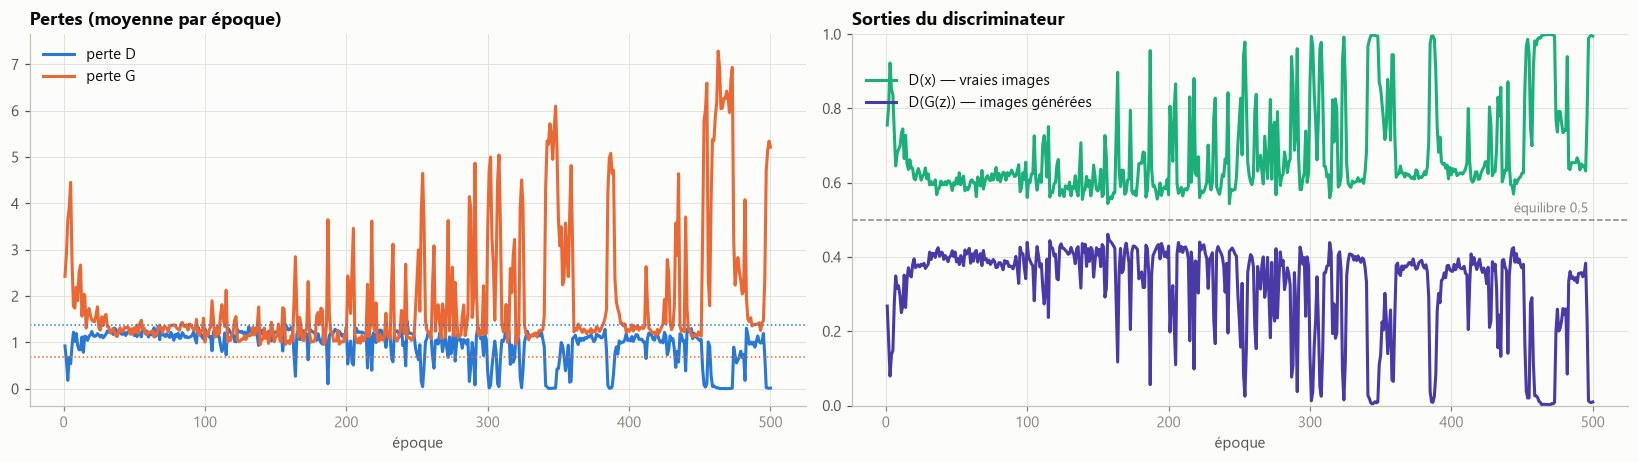

Temps moyen par époque : 1.67 s — 13 000 itérations au total


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
ax = axes[0]
ax.plot(hist["epoch"], hist["loss_d"], color=CAT[0], label="perte D")
ax.plot(hist["epoch"], hist["loss_g"], color=CAT[1], label="perte G")
ax.axhline(np.log(4), color=CAT[0], ls=":", lw=1); ax.axhline(np.log(2), color=CAT[1], ls=":", lw=1)
ax.set_title("Pertes (moyenne par époque)"); ax.set_xlabel("époque"); ax.legend()
ax = axes[1]
ax.plot(hist["epoch"], hist["d_real"], color=CAT[2], label="D(x) — vraies images")
ax.plot(hist["epoch"], hist["d_fake"], color=CAT[6], label="D(G(z)) — images générées")
ax.axhline(0.5, color=MUTED, ls="--", lw=1); ax.text(hist["epoch"].max(), 0.52, "équilibre 0,5 ", ha="right", fontsize=9, color=MUTED)
ax.set_ylim(0, 1); ax.set_title("Sorties du discriminateur"); ax.set_xlabel("époque"); ax.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
plt.tight_layout()
save(fig, "01_dynamics")
plt.show()
print(f"Temps moyen par époque : {hist['seconds'].iloc[1:].mean():.2f} s — {hist['iters'].iloc[-1]:,} itérations au total".replace(",", " "))

**Observations — deux phases très différentes**

1. **Époques 1 à ~180 : l'objectif est atteint.** Le discriminateur ne domine plus : `D(x)` ≈ 0,6 et `D(G(z))` ≈ 0,4,
   bien plus proches de l'équilibre (0,5) que dans le modèle n°1 (0,8 / 0,2). La perte de D se stabilise vers 1,2,
   près de sa valeur d'équilibre théorique (1,39), et celle de G descend à ~1,2 (contre 3 à 5 dans le modèle n°1).
   DiffAugment empêche bien le discriminateur de gagner trop facilement.
2. **À partir de l'époque ~180 : le jeu devient instable.** Des crises de plus en plus violentes apparaissent : la perte
   de G bondit à 5-7, celle de D tombe à ~0, `D(G(z))` s'effondre vers 0. Deux crises longues, vers les époques
   **325-350** et **460-500**, correspondent à de vrais effondrements du générateur (§4). Entre les deux, le jeu revient
   à l'équilibre : le modèle **se rétablit** seul.

DiffAugment a donc rééquilibré le rapport de force, mais pas stabilisé la dynamique : les deux réseaux restent libres
de « sur-réagir » l'un à l'autre.

## 3. Les métriques au fil de l'entraînement

Les lignes horizontales sont les **faux générateurs** du notebook 03 : elles situent le modèle sur l'échelle de lecture.

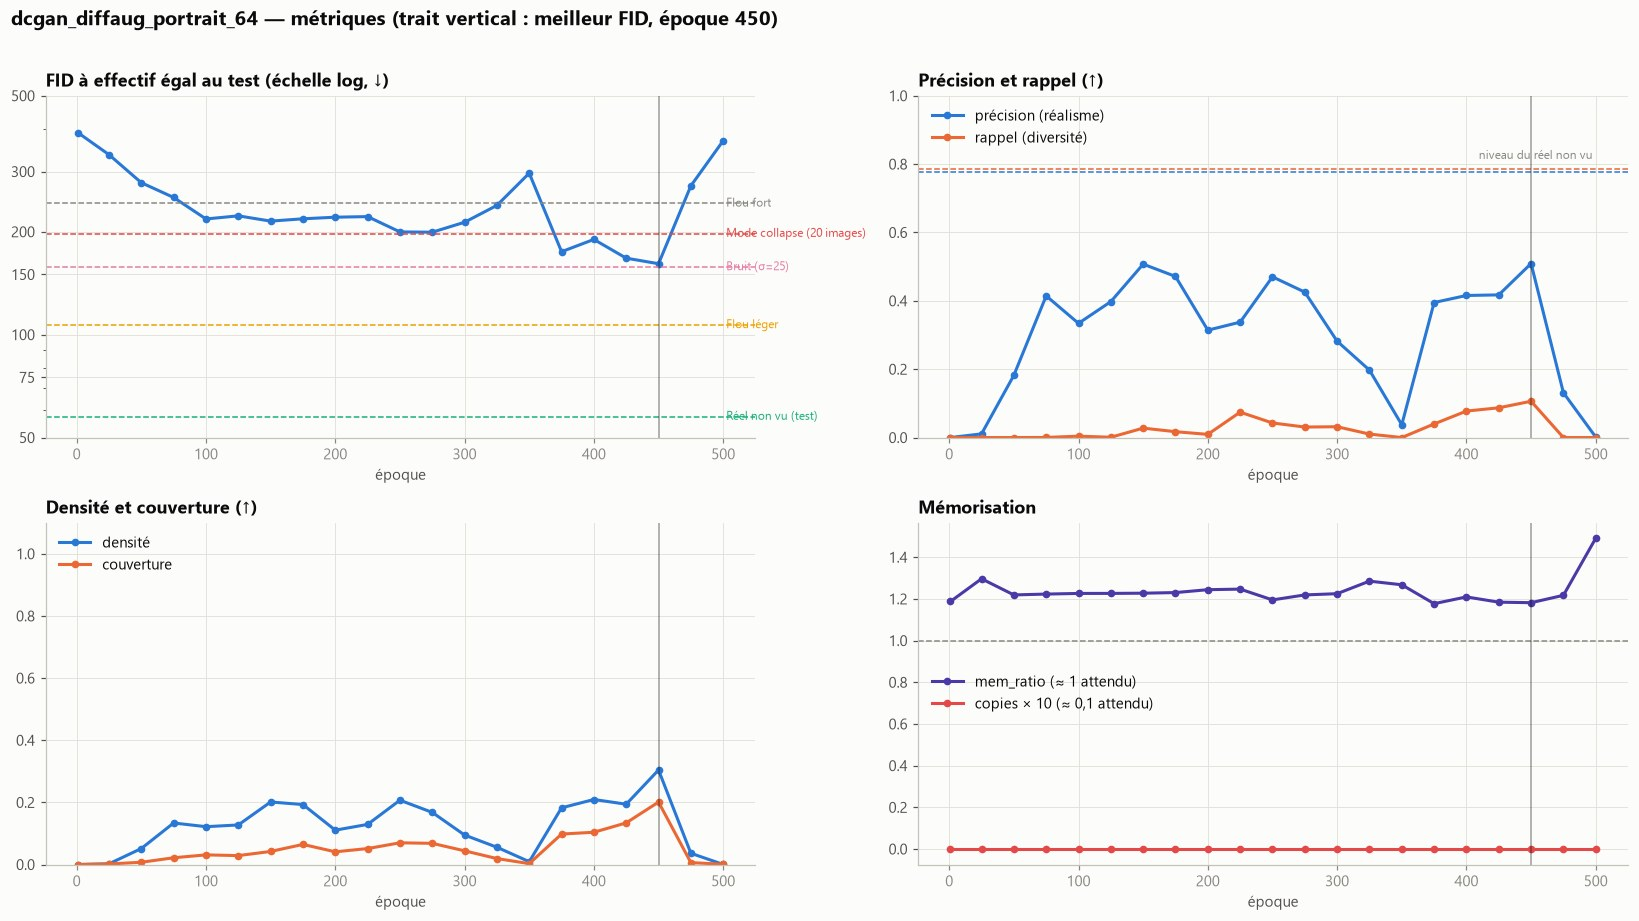

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
0,1,382.239,389.794,451.041,0.000,0.000,0.000,0.000,1.188,0.0
1,25,314.673,336.122,359.160,0.011,0.000,0.002,0.002,1.296,0.0
2,50,250.078,278.268,270.854,0.182,0.000,0.051,0.007,1.219,0.0
3,75,220.672,251.965,230.077,0.414,0.000,0.134,0.022,1.223,0.0
4,100,181.319,217.982,183.322,0.334,0.004,0.122,0.031,1.226,0.0
5,125,184.454,222.604,186.132,0.398,0.001,0.127,0.029,1.226,0.0
6,150,173.982,214.846,169.102,0.507,0.028,0.201,0.042,1.227,0.0
7,175,177.628,218.221,171.181,0.471,0.017,0.193,0.065,1.230,0.0
8,200,178.464,220.596,173.279,0.314,0.009,0.111,0.041,1.244,0.0
9,225,178.018,221.476,170.713,0.338,0.074,0.129,0.051,1.247,0.0


In [5]:
best = ev.loc[ev["FID"].idxmin()]
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))

ax = axes[0, 0]
ax.plot(ev["epoch"], ev["FID_ntest"], color=MAIN, marker="o", ms=4, label=RUN)
for lbl, c in [("Réel non vu (test)", CAT[2]), ("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4]),
               ("Mode collapse (20 images)", CAT[7]), ("Flou fort", MUTED)]:
    ax.axhline(bl.loc[lbl, "FID_ntest"], color=c, ls="--", lw=1)
    ax.text(ev["epoch"].max(), bl.loc[lbl, "FID_ntest"], f" {lbl}", va="center", fontsize=8, color=c)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(mtick.ScalarFormatter()); ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks([50, 75, 100, 150, 200, 300, 500])
ax.set_title("FID à effectif égal au test (échelle log, ↓)"); ax.set_xlabel("époque")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[0, 1]
ax.plot(ev["epoch"], ev["precision"], color=CAT[0], marker="o", ms=4, label="précision (réalisme)")
ax.plot(ev["epoch"], ev["recall"], color=CAT[1], marker="o", ms=4, label="rappel (diversité)")
ax.axhline(bl.loc["Réel non vu (test)", "precision"], color=CAT[0], ls="--", lw=1)
ax.axhline(bl.loc["Réel non vu (test)", "recall"], color=CAT[1], ls="--", lw=1)
ax.text(ev["epoch"].max(), bl.loc["Réel non vu (test)", "recall"] + 0.03, "niveau du réel non vu ", ha="right", fontsize=8, color=MUTED)
ax.set_ylim(0, 1); ax.set_title("Précision et rappel (↑)"); ax.set_xlabel("époque"); ax.legend(loc="upper left")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 0]
ax.plot(ev["epoch"], ev["density"], color=CAT[0], marker="o", ms=4, label="densité")
ax.plot(ev["epoch"], ev["coverage"], color=CAT[1], marker="o", ms=4, label="couverture")
ax.set_ylim(0, max(1.1, ev["density"].max() * 1.1)); ax.set_title("Densité et couverture (↑)"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 1]
ax.plot(ev["epoch"], ev["mem_ratio"], color=CAT[6], marker="o", ms=4, label="mem_ratio (≈ 1 attendu)")
ax.plot(ev["epoch"], ev["copies"] * 10, color=CAT[7], marker="o", ms=4, label="copies × 10 (≈ 0,1 attendu)")
ax.axhline(1, color=MUTED, ls="--", lw=1)
ax.set_title("Mémorisation"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)
fig.suptitle(f"{RUN} — métriques (trait vertical : meilleur FID, époque {int(best['epoch'])})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97))
save(fig, "02_metrics")
plt.show()

ev[["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]].round(3)

**Observations**

- Le FID suit les deux phases : il descend plus vite que le modèle n°1 au début (époques 1-100), plafonne, puis subit
  deux remontées brutales (époques 325-350 : FID jusqu'à 271 ; époques 475-500 : jusqu'à 340) séparées par la
  **meilleure période du run** (époques 375-450).
- **Meilleur checkpoint : époque 450, FID 116** (161 à effectif égal) — c'est le meilleur score obtenu jusqu'ici. À ce
  moment, précision (0,51), rappel (0,11), densité (0,30) et couverture (0,20) sont tous au-dessus du modèle n°1.
- **Le dernier checkpoint est inutilisable** (FID 340, précision 0) : sans la sauvegarde automatique du meilleur
  checkpoint, ce run aurait paru pire que le modèle n°1.
- **Toujours aucune mémorisation** (`mem_ratio` 1,18 ; 0 % de copies).

## 4. Évolution visuelle à bruit fixe

Les grilles sont générées à chaque évaluation à partir des **mêmes vecteurs latents** : on voit chaque « tableau »
se former. On affiche ici les 16 premières images de chaque grille.

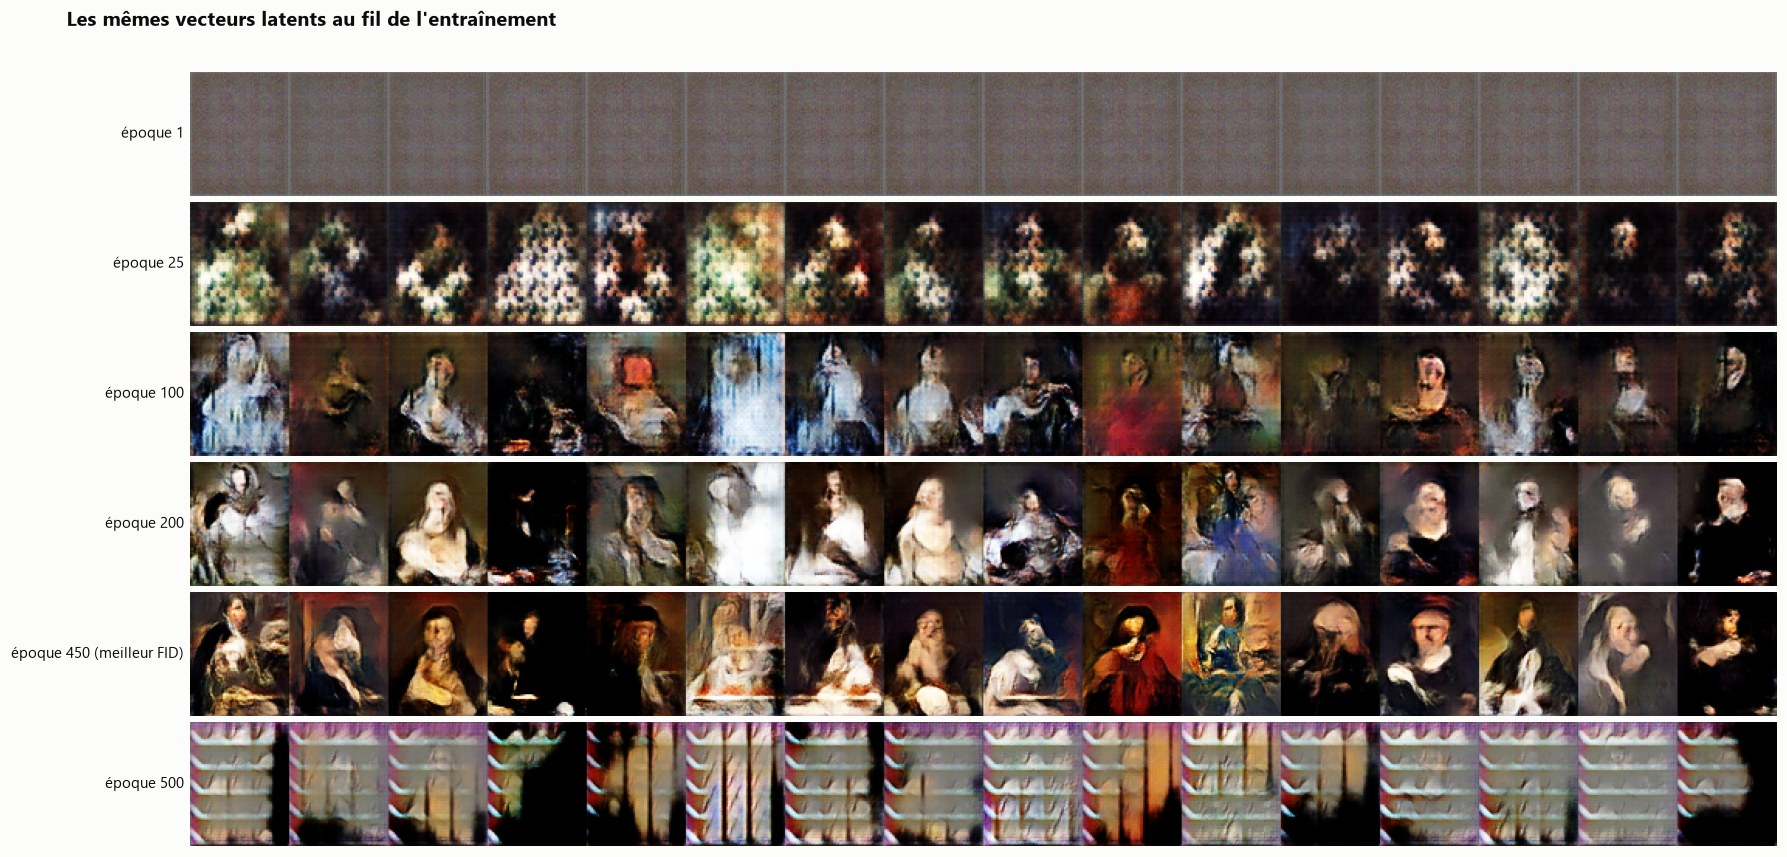

In [6]:
def grid_tiles(path, n=16, ncol=8):
    # Découpe une grille sauvegardée par torchvision (padding 2 px) en tuiles individuelles.
    g = np.asarray(Image.open(path).convert("RGB"))
    w, h, p = SIZE[0], SIZE[1], 2
    return [g[p + (i // ncol) * (h + p): p + (i // ncol) * (h + p) + h, p + (i % ncol) * (w + p): p + (i % ncol) * (w + p) + w]
            for i in range(n)]


epochs_avail = sorted(int(p.stem.split("_")[1]) for p in (RUN_DIR / "samples").glob("epoch_*.png"))
show = sorted({epochs_avail[0], 25, 100, 200, int(best["epoch"]), epochs_avail[-1]} & set(epochs_avail))
fig, axes = plt.subplots(len(show), 1, figsize=(16, 1.25 * len(show) + 0.4))
for ax, e in zip(axes, show):
    tiles = grid_tiles(RUN_DIR / "samples" / f"epoch_{e:04d}.png")
    ax.imshow(np.concatenate(tiles, axis=1)); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    tag = " (meilleur FID)" if e == int(best["epoch"]) else ""
    ax.set_ylabel(f"époque {e}{tag}", rotation=0, ha="right", va="center", fontsize=10, color=INK)
fig.suptitle("Les mêmes vecteurs latents au fil de l'entraînement", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=0.4)
save(fig, "03_evolution")
plt.show()

**Observations** — l'époque 450 donne des portraits plus contrastés et plus variés (poses, couleurs, fonds bleus ou
dorés). L'époque 500 montre un **mode collapse** caractérisé : presque toutes les images deviennent le même motif
gris rayé, quel que soit le vecteur latent — le générateur a trouvé une seule sortie qui trompe provisoirement le
discriminateur.

Pendant la première crise (époque 325, grille non montrée ici, voir `runs/dcgan_diffaug_portrait_64/samples/`), les
images se remplissent d'un motif d'ovales clairs répétés en mosaïque. **Hypothèse** (non vérifiée) : en dupliquant des
« visages » sur toute l'image, le générateur s'assure qu'il en reste un de visible après une translation ou un cutout
— il exploiterait les augmentations elles-mêmes. Ce serait un cas d'école de GAN qui optimise le critère plutôt que
l'objectif réel.

## 5. Le meilleur checkpoint

On recharge le générateur au meilleur FID et on compare ses images à de vraies peintures du train, à la même
résolution.

Checkpoint de l'époque 450 — FID 116.4


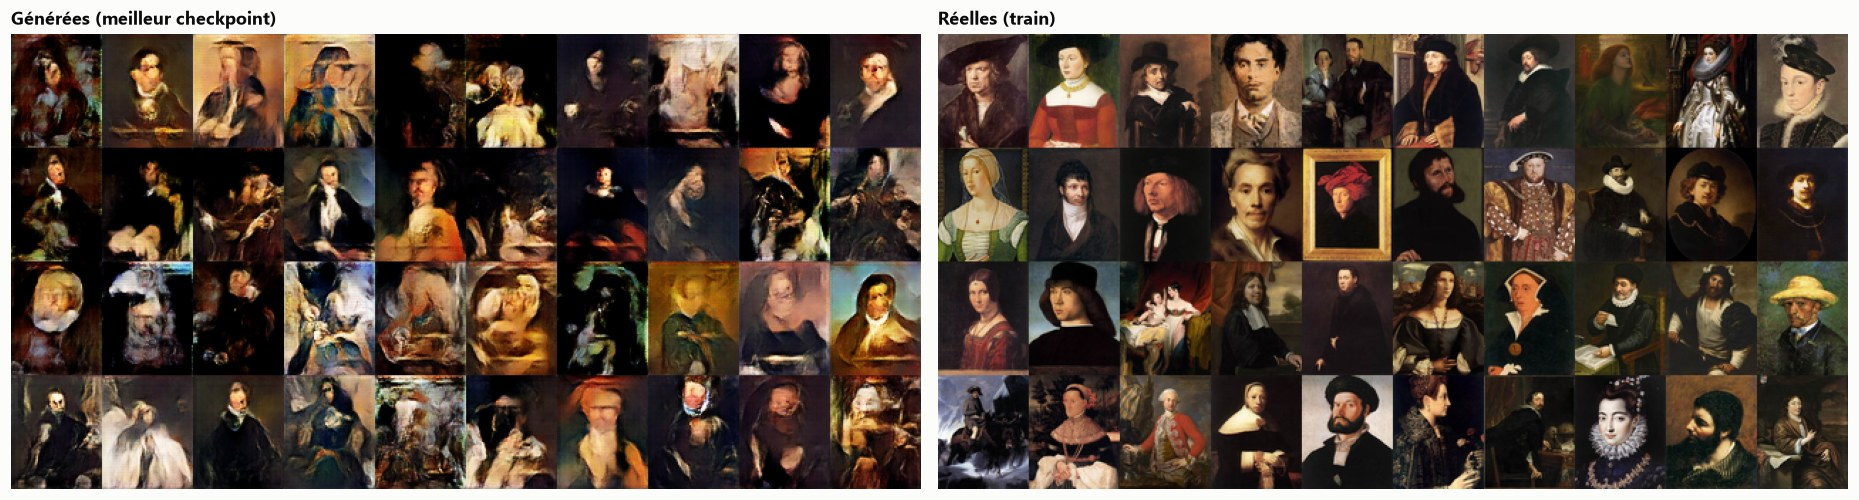

In [7]:
ckpt = torch.load(RUN_DIR / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"]).to(DEVICE)
G.load_state_dict(ckpt["G"])
print(f"Checkpoint de l'époque {ckpt['epoch']} — FID {ckpt['scores']['FID']:.1f}")

z = torch.randn(40, cfg["nz"], generator=torch.Generator().manual_seed(123)).to(DEVICE)
fake = tr.generate(G, z).permute(0, 2, 3, 1).cpu().numpy()
real = ds.load_split(cfg["genre"], "train", SIZE)
real = real[np.random.default_rng(123).choice(len(real), 40, replace=False)]


def mosaic(imgs, ncol=10):
    rows = [np.concatenate(imgs[i:i + ncol], axis=1) for i in range(0, len(imgs), ncol)]
    return np.concatenate(rows, axis=0)


fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))
for ax, imgs, title in [(axes[0], fake, "Générées (meilleur checkpoint)"), (axes[1], real, "Réelles (train)")]:
    ax.imshow(mosaic(list(imgs))); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "04_best_vs_real")
plt.show()

### 5.1 Contrôle visuel de la mémorisation

Pour quelques images générées, on cherche l'image du train la plus proche dans l'espace d'Inception. Si le générateur
recopiait, on retrouverait la même œuvre.

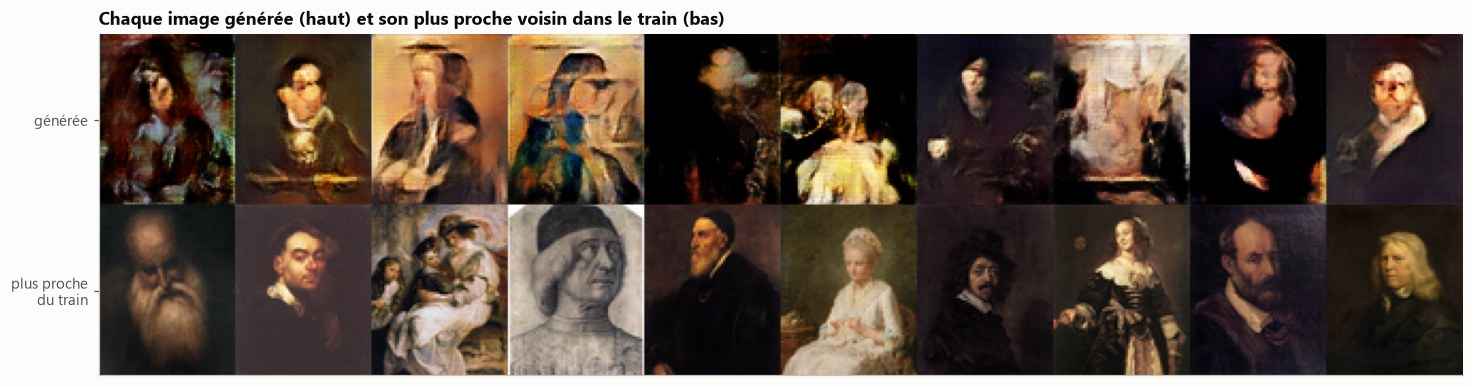

In [8]:
ref = mt.Reference.load_or_compute(cfg["genre"], SIZE, ds.DATASETS / cfg["genre"])
f_fake, _ = mt.extract_features(fake[:10])
d = torch.cdist(torch.from_numpy(f_fake).float(), torch.from_numpy(ref.train).float())
nn_idx = d.argmin(1).numpy()
train_all = ds.load_split(cfg["genre"], "train", SIZE)
fig, ax = plt.subplots(figsize=(16, 4.2))
top = np.concatenate(list(fake[:10]), axis=1)
bottom = np.concatenate([train_all[i] for i in nn_idx], axis=1)
ax.imshow(np.concatenate([top, bottom], axis=0)); ax.set_xticks([]); ax.set_yticks([SIZE[1] / 2, SIZE[1] * 1.5], ["générée", "plus proche\ndu train"])
ax.grid(False)
ax.set_title("Chaque image générée (haut) et son plus proche voisin dans le train (bas)")
save(fig, "05_nearest_neighbors")
plt.show()

### 5.2 Interpolation dans l'espace latent

Autre test de la veille (question 7) : on relie deux vecteurs latents et on génère les images intermédiaires. Des
transitions **progressives** indiquent que le générateur a appris un espace continu de « tableaux possibles » ; des
sauts brusques trahiraient un apprentissage par cœur de quelques images.

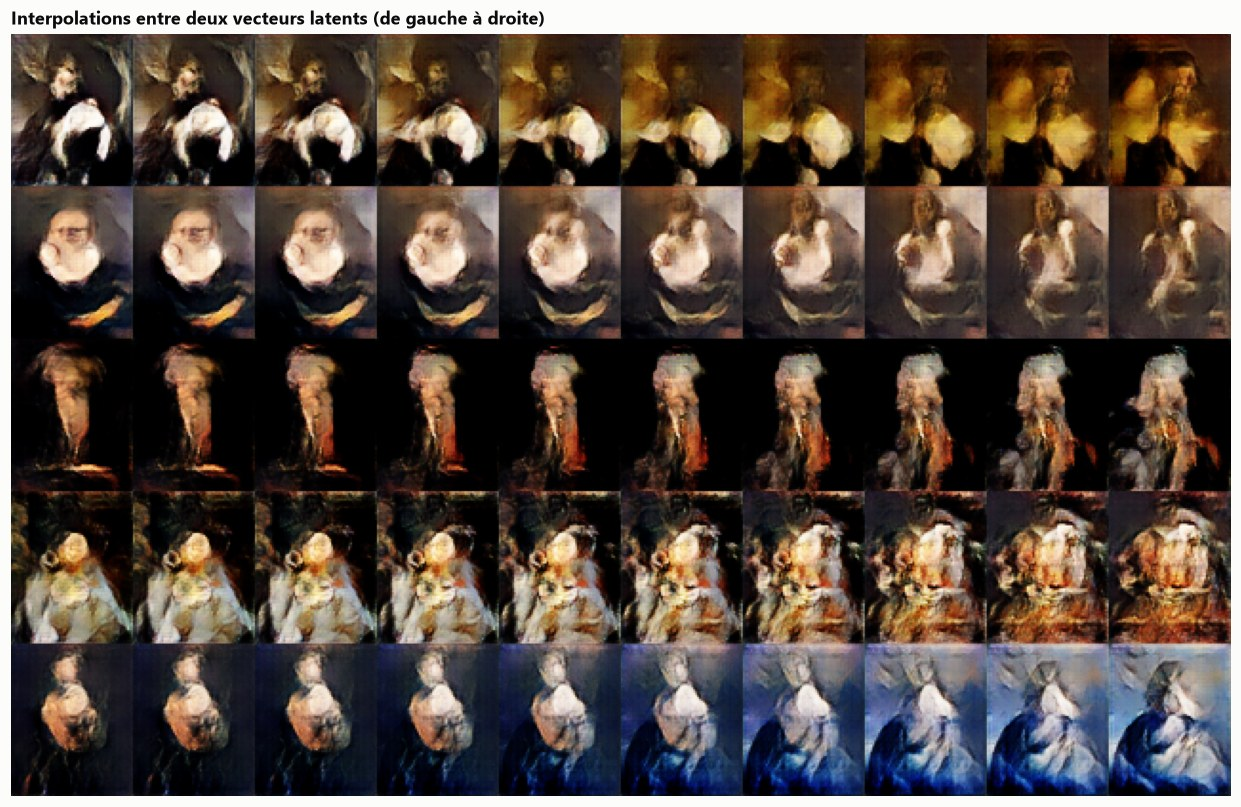

In [9]:
def slerp(a, b, t):
    # Interpolation sphérique : reste à la « bonne distance » de l'origine, comme les vecteurs gaussiens.
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


g = torch.Generator().manual_seed(7)
steps = torch.linspace(0, 1, 10)
rows = []
for _ in range(5):
    a, b = torch.randn(cfg["nz"], generator=g), torch.randn(cfg["nz"], generator=g)
    zs = torch.stack([slerp(a, b, t) for t in steps]).to(DEVICE)
    rows.append(np.concatenate(list(tr.generate(G, zs).permute(0, 2, 3, 1).cpu().numpy()), axis=1))
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(np.concatenate(rows, axis=0)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "06_interpolation")
plt.show()

**Observations** — au meilleur checkpoint, les images gardent le caractère « portrait peint » du modèle n°1, avec une
palette un peu plus riche. **Les visages restent déformés** : DiffAugment agit sur l'équilibre du jeu, pas sur la
capacité du réseau à dessiner des structures fines à cette résolution. Les plus proches voisins sont d'autres œuvres
(pas de copie) et les interpolations restent continues.

## 6. Comparaison avec les modèles précédents

Tous les runs du même genre et de la même résolution sont retrouvés automatiquement dans `runs/`. Même données,
même protocole d'évaluation : les écarts viennent uniquement de ce qui a changé entre les modèles.

Runs comparés : ['dcgan_diffaug_portrait_64', 'dcgan_portrait_64']


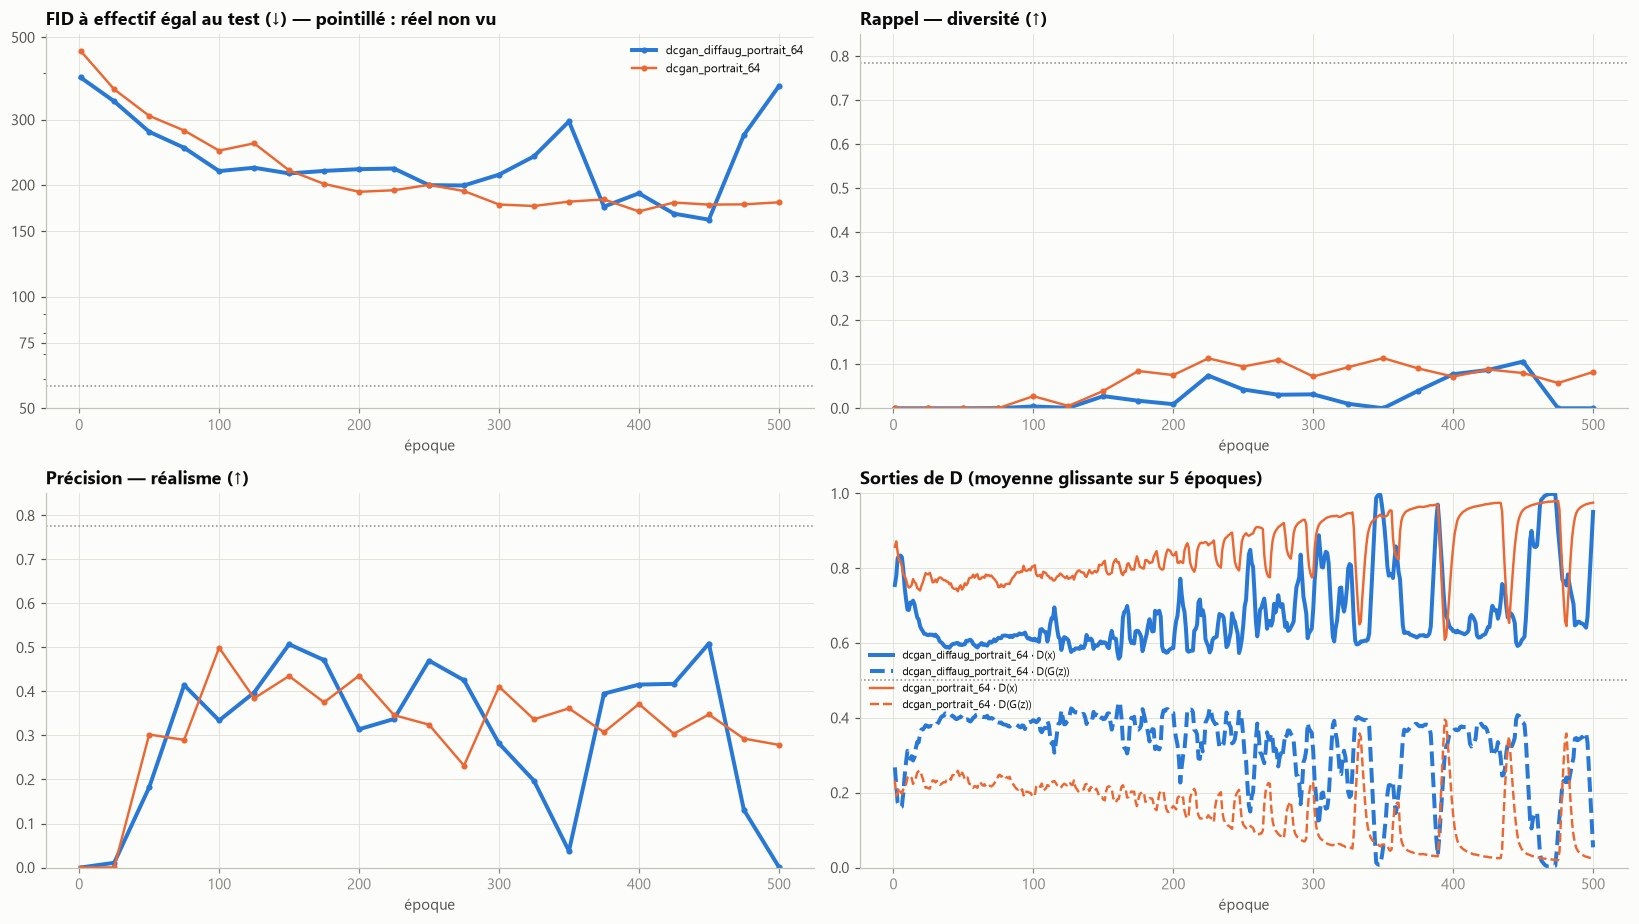

In [10]:
others = []
for p in sorted((ROOT / "runs").glob("*/config.json")):
    c = json.loads(p.read_text(encoding="utf-8"))
    if c["genre"] == cfg["genre"] and tuple(c["size"]) == SIZE and (p.parent / "eval.csv").exists():
        others.append((p.parent.name, pd.read_csv(p.parent / "eval.csv"), pd.read_csv(p.parent / "history.csv")))
print("Runs comparés :", [n for n, _, _ in others])

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
for k, (name, e, h) in enumerate(others):
    col, lw = CAT[k % len(CAT)], 2.6 if name == RUN else 1.6
    axes[0, 0].plot(e["epoch"], e["FID_ntest"], color=col, lw=lw, marker="o", ms=3, label=name)
    axes[0, 1].plot(e["epoch"], e["recall"], color=col, lw=lw, marker="o", ms=3, label=name)
    axes[1, 0].plot(e["epoch"], e["precision"], color=col, lw=lw, marker="o", ms=3, label=name)
    axes[1, 1].plot(h["epoch"], h["d_real"].rolling(5, min_periods=1).mean(), color=col, lw=lw, label=f"{name} · D(x)")
    axes[1, 1].plot(h["epoch"], h["d_fake"].rolling(5, min_periods=1).mean(), color=col, lw=lw, ls="--", label=f"{name} · D(G(z))")
axes[0, 0].axhline(bl.loc["Réel non vu (test)", "FID_ntest"], color=MUTED, ls=":", lw=1)
axes[0, 0].set_yscale("log"); axes[0, 0].yaxis.set_major_formatter(mtick.ScalarFormatter())
axes[0, 0].yaxis.set_minor_formatter(mtick.NullFormatter()); axes[0, 0].set_yticks([50, 75, 100, 150, 200, 300, 500])
axes[0, 0].set_title("FID à effectif égal au test (↓) — pointillé : réel non vu")
axes[0, 1].axhline(bl.loc["Réel non vu (test)", "recall"], color=MUTED, ls=":", lw=1)
axes[0, 1].set_title("Rappel — diversité (↑)"); axes[0, 1].set_ylim(0, 0.85)
axes[1, 0].axhline(bl.loc["Réel non vu (test)", "precision"], color=MUTED, ls=":", lw=1)
axes[1, 0].set_title("Précision — réalisme (↑)"); axes[1, 0].set_ylim(0, 0.85)
axes[1, 1].axhline(0.5, color=MUTED, ls=":", lw=1); axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Sorties de D (moyenne glissante sur 5 époques)")
for ax in axes.flat:
    ax.set_xlabel("époque")
axes[0, 0].legend(fontsize=8); axes[1, 1].legend(fontsize=7.5, loc="center left")
plt.tight_layout()
save(fig, "07_comparison")
plt.show()

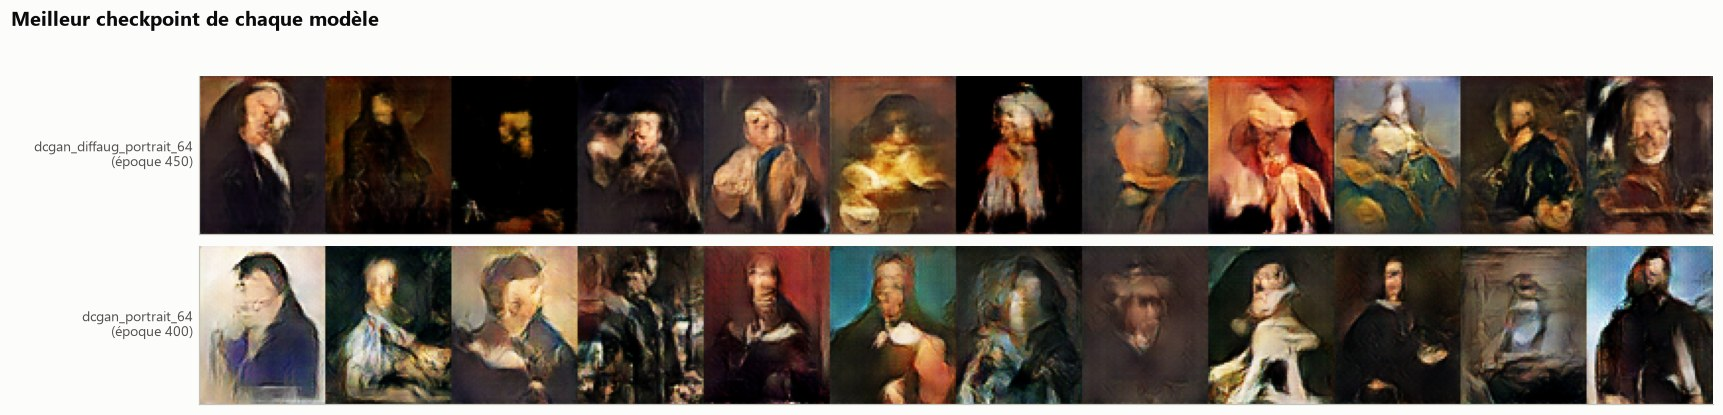

In [11]:
# Mêmes vecteurs latents, meilleur checkpoint de chaque modèle
z_cmp = torch.randn(12, cfg["nz"], generator=torch.Generator().manual_seed(2024)).to(DEVICE)
strips = []
for name, _, _ in others:
    ck = torch.load(ROOT / "runs" / name / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
    c = ck["config"]
    g = Generator(c["nz"], c["ngf"], base_grid(tuple(c["size"]), c["n_up"]), c["n_up"]).to(DEVICE)
    g.load_state_dict(ck["G"])
    strips.append((name, ck["epoch"], np.concatenate(list(tr.generate(g, z_cmp).permute(0, 2, 3, 1).cpu().numpy()), axis=1)))
fig, axes = plt.subplots(len(strips), 1, figsize=(16, 1.75 * len(strips) + 0.3), squeeze=False)
for ax, (name, ep, strip) in zip(axes[:, 0], strips):
    ax.imshow(strip); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_ylabel(f"{name}\n(époque {ep})", rotation=0, ha="right", va="center", fontsize=9)
fig.suptitle("Meilleur checkpoint de chaque modèle", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "08_comparison_samples")
plt.show()

**Observations**

- **Au meilleur checkpoint, DiffAugment fait mieux sur toutes les métriques** : FID 116 contre 130 (−11 %), précision
  0,51 contre 0,37, rappel 0,11 contre 0,07, couverture 0,20 contre 0,11.
- **Mais la courbe est bien plus chaotique.** Le modèle n°1 progresse lentement et régulièrement vers un plateau ; le
  modèle n°2 alterne excellentes périodes et effondrements.
- Sur les sorties de D (en bas à droite), on voit la différence de nature : le modèle n°1 dérive lentement vers un
  discriminateur écrasant ; le modèle n°2 reste proche de l'équilibre la plupart du temps, mais avec des décrochages
  soudains.
- **Prudence sur l'écart de FID** : chaque modèle n'a été entraîné qu'une fois, avec une seule graine. Les GAN sont
  très sensibles à l'initialisation ; une partie de l'écart (130 contre 116) peut venir du hasard. Pour l'affirmer
  solidement, il faudrait répéter chaque entraînement avec 2 ou 3 graines.

## 7. Bilan chiffré

In [12]:
reg = pd.read_csv(ROOT / "reports" / "metrics" / "models.csv")
cols = ["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
# Tous les modèles du même genre et de la même résolution, puis les faux générateurs de référence
same = reg[(reg["genre"] == cfg["genre"]) & (reg["size"] == f"{SIZE[0]}x{SIZE[1]}")]
mine = same.set_index(same["run"] + " · " + same["checkpoint"])[cols]
refs = bl.loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Mode collapse (20 images)", "Flou fort"],
              [c for c in cols if c != "epoch"]]
refs.index = "réf. · " + refs.index
pd.concat([mine, refs]).round(3)

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
dcgan_portrait_64 · best,400.0,129.988,169.740,119.640,0.372,0.072,0.166,0.109,1.199,0.000
dcgan_portrait_64 · last,500.0,137.645,179.586,135.064,0.279,0.082,0.116,0.094,1.225,0.000
dcgan_diffaug_portrait_64 · best,450.0,116.392,161.252,100.441,0.509,0.106,0.304,0.201,1.182,0.000
dcgan_diffaug_portrait_64 · last,500.0,339.505,369.273,399.580,0.001,0.000,0.000,0.001,1.491,0.000
réf. · Réel non vu (test),NaN,57.562,57.562,-0.223,0.776,0.785,0.913,0.396,1.000,0.010
réf. · Flou léger,NaN,61.232,106.555,56.554,0.684,0.712,0.268,0.671,1.025,0.029
réf. · Bruit (σ=25),NaN,113.950,157.661,121.322,0.141,0.237,0.037,0.111,1.177,0.001
réf. · Mode collapse (20 images),NaN,196.333,197.167,15.759,1.000,0.006,0.999,0.029,0.001,1.000
réf. · Flou fort,NaN,203.407,241.989,213.972,0.026,0.019,0.005,0.004,1.337,0.000


## 8. Conclusion

| | Modèle n°1 : DCGAN | Modèle n°2 : + DiffAugment |
|---|---|---|
| Meilleur FID (époque) | 130 (400) | **116** (450) |
| FID à effectif égal | 170 | **161** |
| Précision / rappel | 0,37 / 0,07 | **0,51 / 0,11** |
| Couverture | 0,11 | **0,20** |
| Mémorisation | aucune | aucune |
| FID final (époque 500) | 138 | 340 (effondrement) |
| Stabilité | régulier, plateau | **instable**, 2 effondrements |

**Ce que DiffAugment a apporté** : il a résolu le problème visé — le discriminateur ne domine plus — et le meilleur
checkpoint est le meilleur modèle obtenu jusqu'ici, sur toutes les métriques.

**Ce qu'il a révélé** : une fois le discriminateur privé de son avantage, l'entraînement devient **instable**, avec des
effondrements du générateur. Deux enseignements pratiques :
1. **Sauvegarder le meilleur checkpoint est indispensable** : le modèle final de ce run est inutilisable.
2. **Il manque un mécanisme de stabilisation.**

**Prochain modèle (n°3)** — garder DiffAugment et ajouter la **normalisation spectrale** au discriminateur, avec une
**perte hinge** (Miyato et al., 2018). La normalisation spectrale borne la « pente » du discriminateur (constante de
Lipschitz) : il ne peut plus réagir brutalement à un petit changement du générateur, ce qui vise directement les crises
observées ici. Hypothèse mesurable : même niveau de FID au meilleur checkpoint, mais **une courbe sans effondrement** et
un dernier checkpoint proche du meilleur.